In [9]:
import nets
import copy
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#Mismo sistema que para temporal difference pero sin politica definida

X = np.linspace(-5, 5, 101)   # estados discretos
A = np.linspace(-1, 1, 31)    # acciones discretas
print(A)

Q = np.zeros((len(X), len(A)))

def closest_state(x):
    return np.argmin(np.abs(X - x))

def step(x, u): #Recompensa un poco más sofisticada, añadiendo el parámetro done y una recompensa mayor si llega al objetivo
    x_next = x + u
    x_next = np.clip(x_next, -20, 20) 
    r = -x_next**2 - 0.05 * u**2
    done = (abs(x_next) < 0.05)
    if done:
        r += 50
    elif abs(x_next) > 9.5:
        r -= 50
        done = True
        
    return x_next, r, done

[-1.         -0.93333333 -0.86666667 -0.8        -0.73333333 -0.66666667
 -0.6        -0.53333333 -0.46666667 -0.4        -0.33333333 -0.26666667
 -0.2        -0.13333333 -0.06666667  0.          0.06666667  0.13333333
  0.2         0.26666667  0.33333333  0.4         0.46666667  0.53333333
  0.6         0.66666667  0.73333333  0.8         0.86666667  0.93333333
  1.        ]


## DQN

Ahora Q está representado en una red neuronal (implementación en nets.py), su actualización sigue el mismo método que en temporal difference, los pasos de actualización se definen a partir de la red objetivo (Q_target) tomando como input la acción de la red original (Q) que es la que es actualizada constantemente. Cada 500 episodios Q se copia a Q_target. 

In [11]:
Q = nets.QNet(n_a = 31, n_s = 1)
Q_target = copy.deepcopy(Q)

N = 20000
eps = 0.2
gamma = 0.95
lr = 0.001

Q_mean_history = []
Q_std_history = []

for i in range(N):
    x = np.random.uniform(-5.0,5.0)
    x = np.array([[x]])
    for t in range(40):
        q = Q.forward(x)

        if np.random.rand() < eps: #Elección de la acción con exploracion
            a_idx = np.random.randint(len(A), dtype=np.int64)
        else:
            a_idx = np.argmax(q)

       
        u = A[a_idx]

        x_next, r, done = step(x, u) #Calculo del estado siguiente

        q_next = Q_target.forward(x_next) # Actualización por td con la accion que da el Q maximo
        td_target = r + gamma* (1 - done) * np.max(q_next) 
        td_target = np.clip(td_target, -100, 100)

        q_target = q.copy()
        q_target[a_idx] = td_target # Se actualiza el target

        Q.backward(q_target, a_idx) # Se actualiza la red
        Q.update_weights(lr)
        x = x_next

        if done:
            break 
        
    if i % 500 == 0:
        Q_target = copy.deepcopy(Q)

    if i % 100 == 0:
        xs = np.linspace(-5, 5, 50)
        Q_vals = []

        for x_test in xs:
            x_in = np.array([[x_test]])
            q = Q.forward(x_in)
            Q_vals.append(q)

        Q_vals = np.array(Q_vals)

        Q_mean_history.append(np.mean(Q_vals))
        Q_std_history.append(np.std(Q_vals))





/home/fabri/RL/notebooks/nets.py:118: RuntimeWarning: invalid value encountered in matmul
  self.dL_dW2 = dL_dy @ self.h.T
/home/fabri/RL/notebooks/nets.py:128: RuntimeWarning: invalid value encountered in subtract
  self.W2 -= lr * self.dL_dW2
/home/fabri/RL/notebooks/nets.py:96: RuntimeWarning: invalid value encountered in add
  self.z1 = self.W1 @ self.x + self.b1


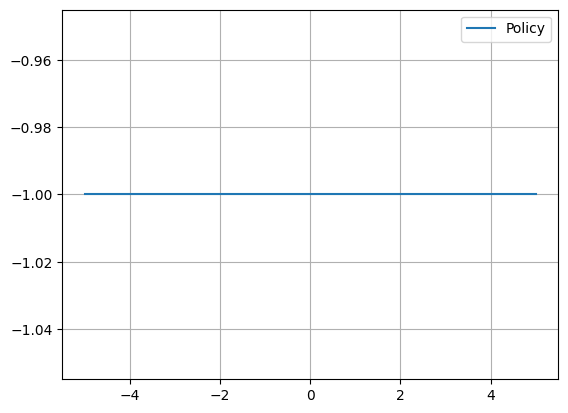

In [12]:
policy = np.array([
    A[np.argmax(Q.forward(np.array([[x]])))]
    for x in X
])

plt.plot(X, policy)
plt.legend(["Policy"])
plt.grid()
plt.show()

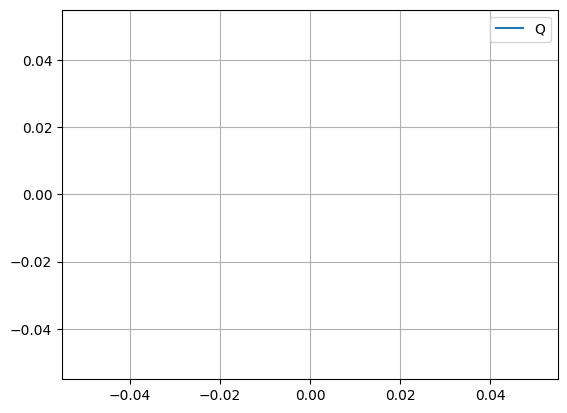

In [13]:
x = 2.0
q = Q.forward(np.array([[x]])).flatten()

plt.plot(A, q)
plt.legend("Q[2]")
plt.grid()
plt.show()

## Añadido de Replay Buffer

Permite acumular muestras en un buffer y entrenar sampleando de él aleatoriamente. Esto elimina la dependencia temporal entre muestras y hace posible utilizar la misma experiencia varias veces para entrenar. El resultado es una política más suave en la misma cantidad de episodios. Se ven resultados más altos en la media y varianza de Q ya que las recompensas altas se propagaron más lejos en el espacio de estados.

In [14]:
buffer = nets.ReplayBuffer(5000, 1, 1)

Q = nets.QNet(n_a = 31, n_s = 1)
Q_target = copy.deepcopy(Q)

N = 20000
eps = 0.2
gamma = 0.95
lr = 0.001
batch_size = 64
update_rate = 2

Q_mean_history_rb = []
Q_std_history_rb = []

for i in range(N):
    x = np.random.uniform(-5.0,5.0)
    x = np.array([[x]])
    for t in range(40):
        q = Q.forward(x)

        if np.random.rand() < eps:
            a_idx = np.random.randint(len(A), dtype=np.int64)
        else:
            a_idx = np.argmax(q)


        u = A[a_idx]

        x_next, r, done = step(x, u)

        buffer.add(x, a_idx, r, x_next, done)

        x = x_next

        if buffer.size > batch_size and t % update_rate == 0:
            
            batch = buffer.sample(batch_size)
            q = Q.forward(batch[0].T)
            q_next = Q_target.forward(batch[3].T)
            td_target = batch[2].T + gamma * (1 - batch[4].T) * np.max(q_next, axis=0, keepdims=True) 
            td_target = np.clip(td_target, -100, 100)
            q_target = q.copy()
            idx = batch[1].astype(int).flatten()
            q_target[idx, np.arange(batch_size)] = td_target.flatten()

            Q.backward(q_target, idx)
            Q.update_weights(lr)

        if done:
            break

    if i % 500 == 0:
        Q_target = copy.deepcopy(Q)      
    
    
    if i % 100 == 0:
        xs = np.linspace(-5, 5, 50)
        Q_vals = []

        for x_test in xs:
            x_in = np.array([[x_test]])
            q = Q.forward(x_in)
            Q_vals.append(q)

        Q_vals = np.array(Q_vals)

        Q_mean_history_rb.append(np.mean(Q_vals))
        Q_std_history_rb.append(np.std(Q_vals))




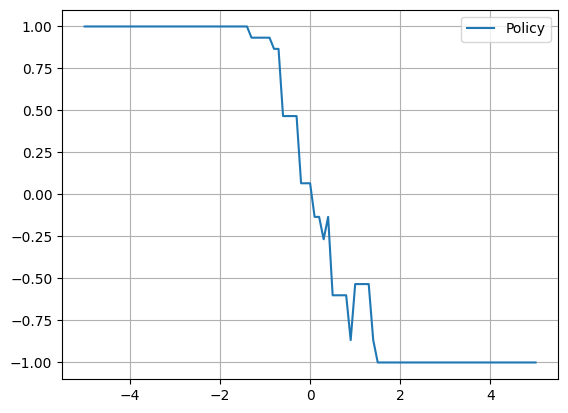

In [15]:
policy = np.array([
    A[np.argmax(Q.forward(np.array([[x]])))]
    for x in X
])

import matplotlib.pyplot as plt

plt.plot(X, policy)
plt.legend(["Policy"])
plt.grid()
plt.show()

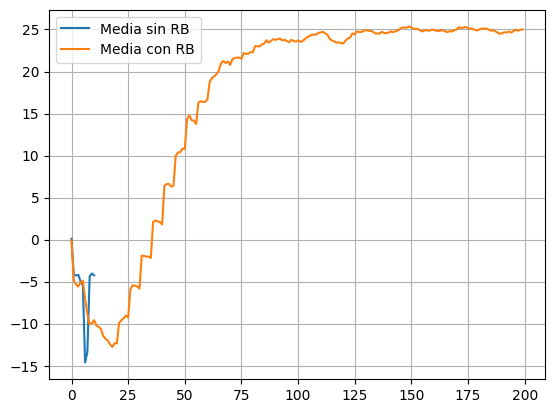

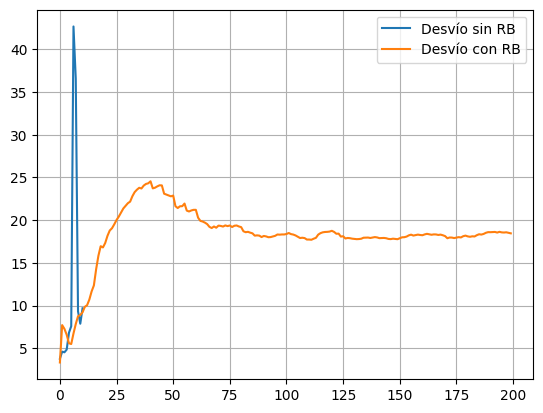

In [16]:

i = np.arange(0, len(Q_std_history))

plt.plot(i, Q_mean_history)
plt.plot(i, Q_mean_history_rb)
plt.legend(["Media sin RB", "Media con RB"])
plt.grid()
plt.show()

plt.plot(i, Q_std_history)
plt.plot(i, Q_std_history_rb)
plt.legend(["Desvío sin RB", "Desvío con RB"])
plt.grid()
plt.show()
